REAL=1, FAKE=0

In [1]:
import pickle
import os
import pickle
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
keras = tf.keras
import tensorflow as tf
from keras import models, layers
from keras import layers, models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, LeakyReLU
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# use jupyter "magic" command to tell it to embed plot into the notebook
import matplotlib.pyplot as plt
%matplotlib inline

# the following code make plots look better
def plot_prettier(dpi=150, fontsize=11, usetex=False):
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters:
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in')
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5)
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5)
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns # to plot the confusion matrix prettier

def conf_matrix(y_test, y_pred, class_names=None):
    """
    helper function computing confusion matrix
    """
    conf_mat = confusion_matrix(y_test, y_pred).T
    conf_mat = conf_mat.astype(float)

    # normalize confusion fraction
    for i in range(len(class_names)):
        conf_mat[i,:] /= float(np.sum(conf_mat[i,:]))

    return conf_mat

def plot_confusion_matrix(y_test, ypred, class_names = None,
                          title=None, figsize=(3,3)):
    conf_mat = conf_matrix(y_test, ypred, class_names=class_names)

    plt.figure(figsize = figsize)
    if title is not None:
        plt.title(title, fontsize=10)
    sns.heatmap(conf_mat.T, square = True, annot=True, fmt='.3f', cmap='Blues', cbar=False,
               xticklabels= class_names,
               yticklabels= class_names)

    plt.xlabel('true label')
    plt.ylabel('predicted label')
    plt.show()

# Load images

In [4]:
# load generated images
with open("pkl_datasets/complete_normalized.pkl", "rb") as f:
    data = pickle.load(f)

images = data["X"]
labels = data["y"]

real_images = images[labels == 1]
fake_images = images[labels == 0]

print(type(data))
print(data.keys())
print(images.shape, images.dtype)
print(labels.shape, labels.dtype)
print(np.bincount(labels))

<class 'dict'>
dict_keys(['X', 'y', 'class_names', 'label_mapping', 'real_paths', 'fake_paths', 'normalization', 'array_shape', 'channel_order'])
(2562, 256, 256, 3) float32
(2562,) int32
[1281 1281]


# Split and prepare data

Train-test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    train_size=0.7,
    random_state=42,
    stratify=labels
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1793, 256, 256, 3) (1793,)
Test: (769, 256, 256, 3) (769,)


Flatten for use with sklearn classifiers (keep the above tensors for CNN)

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat:", X_test_flat.shape)

X_train_flat: (1793, 196608)
X_test_flat: (769, 196608)


# Visualisation

In [7]:
def grz_to_rgb_display(img):
    """
    Stored channel order:  (g, r, z)
    Display channel order: RGB = (z, r, g)
    """
    img = np.asarray(img, dtype=np.float32)

    g = img[:, :, 0]
    r = img[:, :, 1]
    z = img[:, :, 2]

    return np.stack([z, r, g], axis=-1)

def stretch_for_display(img, lo_percentile=1, hi_percentile=99.7):
    """
    Percentile stretch for visualisation only.
    Does not change the stored data.
    """
    img = np.asarray(img, dtype=np.float32)

    lo, hi = np.percentile(img, [lo_percentile, hi_percentile])

    if hi > lo:
        img = (img - lo) / (hi - lo)
    else:
        img = np.zeros_like(img)

    return np.clip(img, 0.0, 1.0)

def plot_tiled_image_grid(
    images,
    labels=None,
    n_images=64,
    ncols=8,
    random_state=42,
    show_real_fake=True,
    balanced=True,
    figsize=(10, 10),
    save_path=None
):
    """
    Plot image grid with optional R/F labels top left

    Parameters
    ----------
    images : np.ndarray
        Image array with shape (N, 256, 256, 3), stored as (g, r, z).

    labels : np.ndarray or None
        Labels with 0 = fake, 1 = real.

    n_images : int
        Number of images to show.

    ncols : int
        Number of columns.

    random_state : int
        Random seed.

    show_real_fake : bool
        If True, write R/F in white at top-left.

    balanced : bool
        If True, require equal numbers of real and fake images.

    figsize : tuple
        Figure size.

    save_path : str or None
        If not None, save figure there.
    """
    rng = np.random.default_rng(random_state)

    images = np.asarray(images)

    if labels is not None:
        labels = np.asarray(labels)

        if len(images) != len(labels):
            raise ValueError(
                f"images and labels must have same length, got {len(images)} and {len(labels)}."
            )

    if (show_real_fake or balanced) and labels is None:
        raise ValueError("labels must be provided if show_real_fake=True or balanced=True.")

    if balanced:
        if n_images % 2 != 0:
            raise ValueError("n_images must be even when balanced=True.")

        n_each = n_images // 2

        fake_indices = np.where(labels == 0)[0]
        real_indices = np.where(labels == 1)[0]

        if len(fake_indices) < n_each:
            raise ValueError(f"Need {n_each} fake images, but only found {len(fake_indices)}.")

        if len(real_indices) < n_each:
            raise ValueError(f"Need {n_each} real images, but only found {len(real_indices)}.")

        selected_fake = rng.choice(fake_indices, size=n_each, replace=False)
        selected_real = rng.choice(real_indices, size=n_each, replace=False)

        selected_indices = np.concatenate([selected_fake, selected_real])
        rng.shuffle(selected_indices)

    else:
        if len(images) < n_images:
            raise ValueError(f"Requested {n_images} images, but only have {len(images)}.")

        selected_indices = rng.choice(len(images), size=n_images, replace=False)

    nrows = int(np.ceil(n_images / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        gridspec_kw={"wspace": 0.0, "hspace": 0.0}
    )

    fig.patch.set_facecolor("black")

    axes = np.asarray(axes).ravel()

    for ax in axes:
        ax.set_facecolor("black")
        ax.axis("off")

    for ax, idx in zip(axes, selected_indices):
        img = images[idx]

        img_rgb = grz_to_rgb_display(img)
        img_rgb = stretch_for_display(img_rgb)

        ax.imshow(img_rgb, interpolation="nearest")
        ax.axis("off")

        if show_real_fake:
            rf_label = "R" if labels[idx] == 1 else "F"
            ax.text(
                0.03, 0.97,
                rf_label,
                color="white",
                fontsize=12,
                fontweight="bold",
                ha="left",
                va="top",
                transform=ax.transAxes
            )

    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
        wspace=0,
        hspace=0
    )

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=200,
            bbox_inches=None,
            pad_inches=0,
            facecolor="black"
        )

    plt.show()

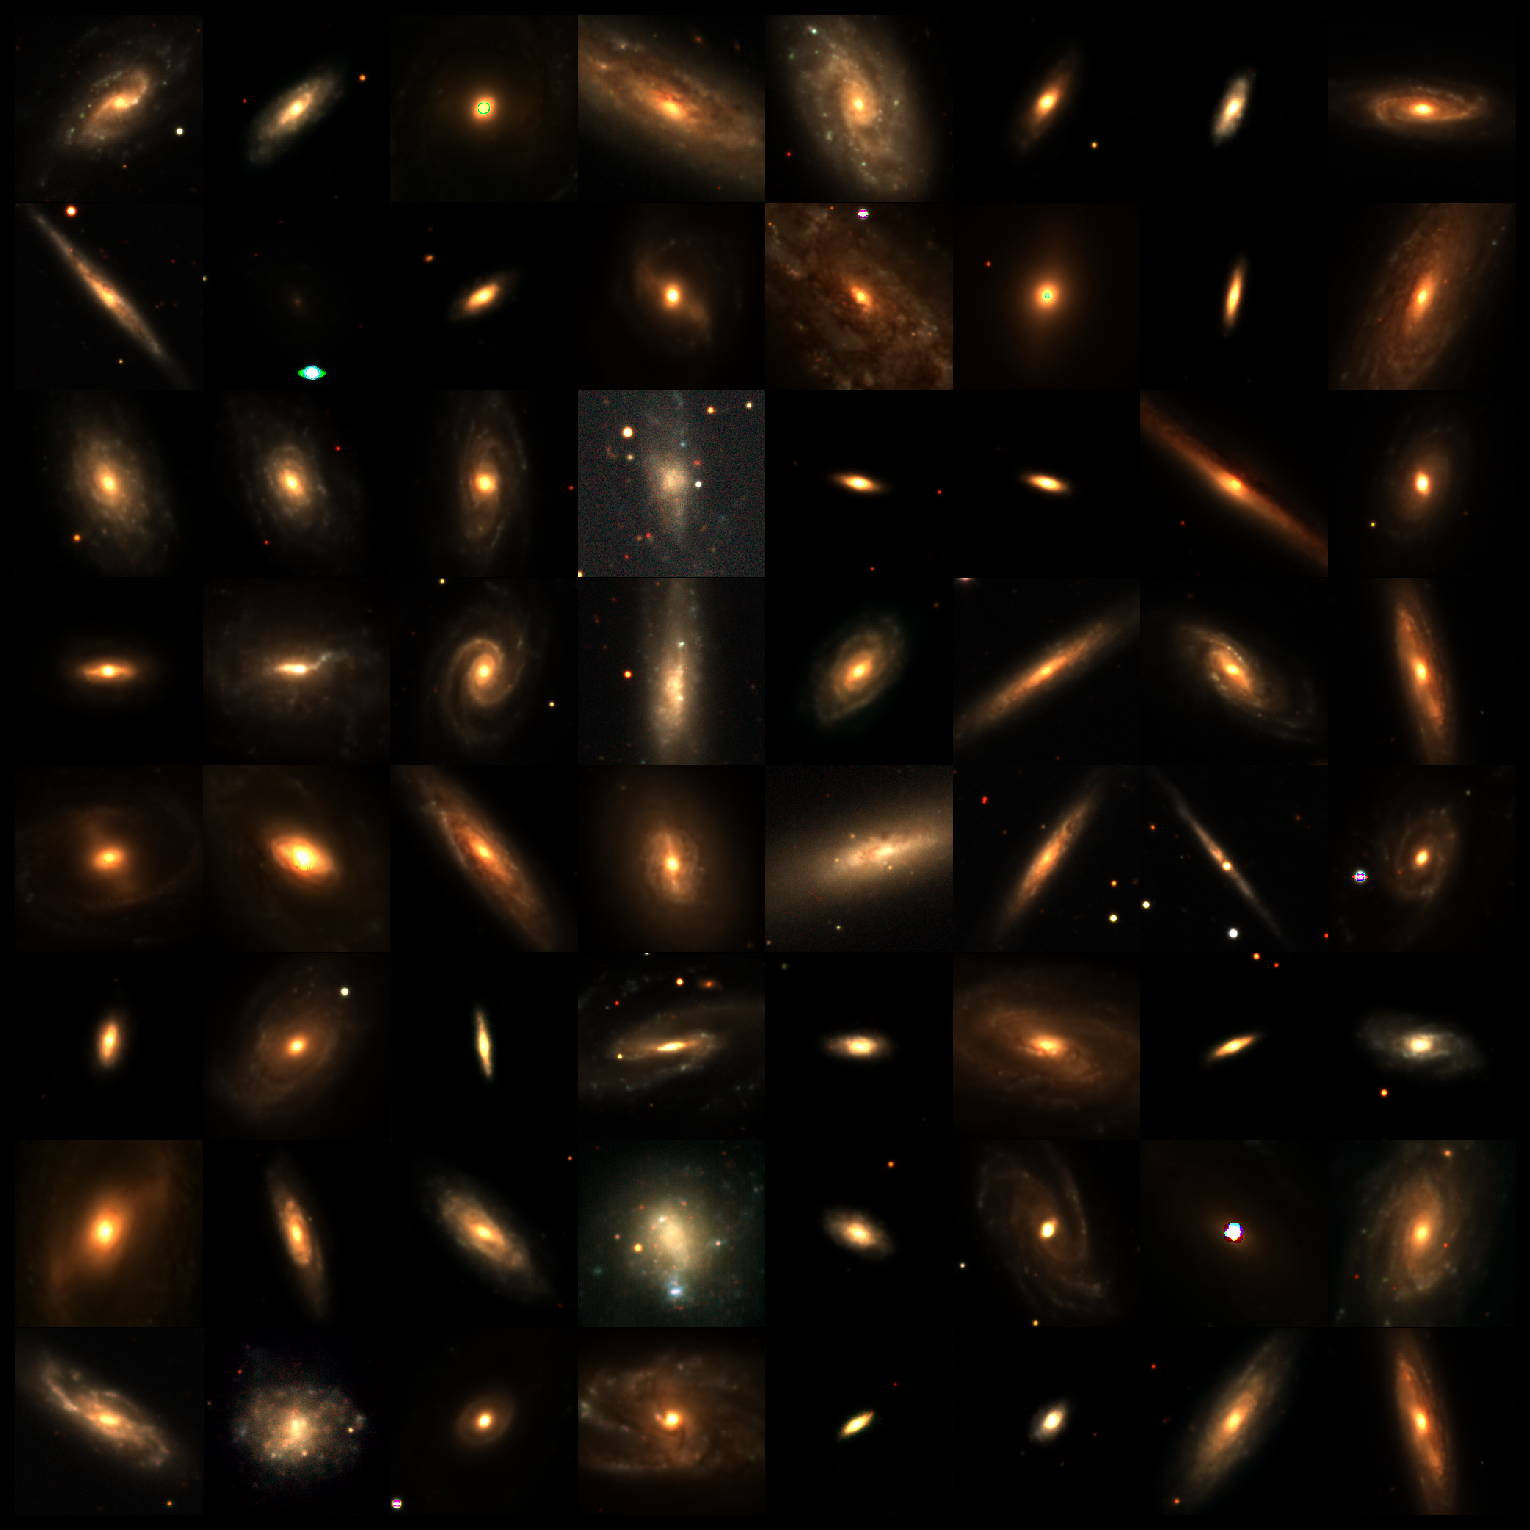

In [8]:
plot_tiled_image_grid(
    images,
    labels=labels,
    n_images=64,
    ncols=8,
    random_state=42,
    show_real_fake=False,
    balanced=True,
    figsize=(10, 10),
    save_path="real_fake_grid_64_nolabel.png"
)

# -----------------------------------------------------------
# Classification

## Basic CNN

In [9]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train_cnn = X_train.copy().astype("float32")
X_test_cnn = X_test.copy().astype("float32")

y_train_cnn = y_train.copy()
y_test_cnn = y_test.copy()

X_train_cnn = np.nan_to_num(X_train_cnn, nan=0.0, posinf=0.0, neginf=0.0)
X_test_cnn = np.nan_to_num(X_test_cnn, nan=0.0, posinf=0.0, neginf=0.0)

mean_cnn = np.mean(X_train_cnn)
std_cnn = np.std(X_train_cnn)

X_train_cnn = (X_train_cnn - mean_cnn) / std_cnn
X_test_cnn = (X_test_cnn - mean_cnn) / std_cnn

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_cnn,
    y_train_cnn,
    test_size=0.2,
    stratify=y_train_cnn,
    random_state=42
)

In [10]:
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64
)

2026-05-28 18:31:47.675086: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-28 18:31:47.675316: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-28 18:31:47.675372: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-28 18:31:47.675585: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-28 18:31:47.675606: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/15


2026-05-28 18:31:48.543886: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.5300 - auc: 0.5283 - loss: 1.2482 - val_accuracy: 0.5627 - val_auc: 0.6390 - val_loss: 0.6693
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.5872 - auc: 0.6405 - loss: 0.6659 - val_accuracy: 0.6184 - val_auc: 0.6746 - val_loss: 0.6504
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6116 - auc: 0.6807 - loss: 0.6556 - val_accuracy: 0.6100 - val_auc: 0.6754 - val_loss: 0.6557
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6227 - auc: 0.6579 - loss: 0.6412 - val_accuracy: 0.6267 - val_auc: 0.6701 - val_loss: 0.6645
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6590 - auc: 0.7023 - loss: 0.6184 - val_accuracy: 0.6267 - val_auc: 0.6820 - val_loss: 0.7054
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6611 - auc: 0.7170 - loss: 0.6430 - val_accuracy: 0.6462 - val_auc: 0.7069 - val_loss: 0.6698
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step

In [11]:
test_loss_cnn, test_acc_cnn, test_auc_cnn = model.evaluate(
    X_test_cnn,
    y_test_cnn
)

print("CNN test accuracy:", test_acc_cnn)
print("CNN test AUC:", test_auc_cnn)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5488 - auc: 0.5475 - loss: 718.5159
CNN test accuracy: 0.5487646460533142
CNN test AUC: 0.547470211982727


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6021 - auc: 0.6615 - loss: 4.8147
Test loss: 4.814743518829346
Test accuracy: 0.6020806431770325
Test AUC: 0.6615259647369385
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


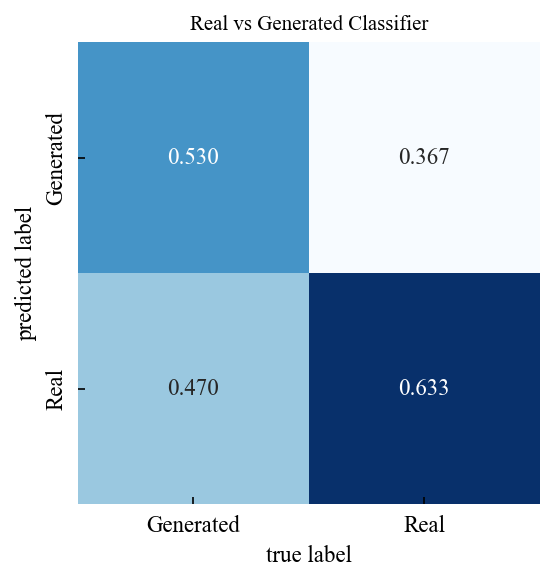

In [12]:
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test AUC:", test_auc)

y_prob = model.predict(X_test_cnn).ravel()
y_pred = (y_prob >= 0.5).astype(int)

class_names = ["Generated", "Real"]

plot_confusion_matrix(
    y_test,
    y_pred,
    class_names=class_names,
    title="Real vs Generated Classifier",
    figsize=(4, 4)
)

# Statistics

### Comparison of pixel statistics

In [13]:
import pandas as pd
import numpy as np

real_image_means = real_images.mean(axis=(1, 2, 3))
fake_image_means = fake_images.mean(axis=(1, 2, 3))

real_image_stds = real_images.std(axis=(1, 2, 3))
fake_image_stds = fake_images.std(axis=(1, 2, 3))

summary_table = pd.DataFrame({
    "quantity": [
        "mean pixel value per image",
        "mean pixel std per image"
    ],
    "real": [
        real_image_means.mean(),
        real_image_stds.mean()
    ],
    "fake": [
        fake_image_means.mean(),
        fake_image_stds.mean()
    ],
})

summary_table["absolute_difference"] = np.abs(
    summary_table["real"] - summary_table["fake"]
)

summary_table

,quantity,real,fake,absolute_difference
0,mean pixel value per image,-0.929804,-0.976618,0.046814
1,mean pixel std per image,0.059574,0.068883,0.009309


In [14]:
real_brightness_variation = real_image_means.std()
fake_brightness_variation = fake_image_means.std()

real_brightness_variation # from image to image

0.08095913

In [15]:
fake_brightness_variation

0.030773936

fake images are darker on average, with slightly greater brightness variation within each image, and are less varied in average brightness from image to image

real images are brighter on average, with slightly lower brightness variation within each image, and are more varied in average brightness from image to image

# Many classifiers

In [16]:
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [17]:
real_pkl_path = "pkl_datasets/real_normalized.pkl"
fake_pkl_path = "pkl_datasets/fake_normalized.pkl"

with open(real_pkl_path, "rb") as f:
    real_images = pickle.load(f)

with open(fake_pkl_path, "rb") as f:
    generated_images = pickle.load(f)

real_images = np.asarray(real_images, dtype=np.float32)
generated_images = np.asarray(generated_images, dtype=np.float32)

# Convert everything to [0, 1] for sklearn
def to_0_1(images):
    images = np.asarray(images, dtype=np.float32)

    if images.min() < 0.0:
        images = (images + 1.0) / 2.0

    if images.max() > 1.0:
        images = images / 255.0

    return np.clip(images, 0.0, 1.0)

real_images = to_0_1(real_images)
generated_images = to_0_1(generated_images)

y_real = np.ones(real_images.shape[0], dtype=np.int32)
y_fake = np.zeros(generated_images.shape[0], dtype=np.int32)

X = np.concatenate([real_images, generated_images], axis=0)
y = np.concatenate([y_real, y_fake], axis=0)

X_flat = X.reshape(X.shape[0], -1)

print("X:", X.shape)
print("X_flat:", X_flat.shape)
print("y:", y.shape)

X: (2562, 256, 256, 3)
X_flat: (2562, 196608)
y: (2562,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

In [19]:
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ),

    "RBF SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        max_iter=300,
        random_state=42
    )
}

In [20]:
results = []

trained_models = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, random_state=42)),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    # AUC needs probabilities or decision scores
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe.named_steps["clf"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        y_score = y_pred

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)

    results.append({
        "model": name,
        "accuracy": acc,
        "auc": auc
    })

    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
results_df


Training Logistic Regression...

Training Linear SVM...

Training RBF SVM...

Training KNN...

Training Random Forest...

Training Gradient Boosting...

Training Gaussian Naive Bayes...

Training MLP...


,model,accuracy,auc
5,Gradient Boosting,0.964912,0.993905
3,KNN,0.955166,0.989467
2,RBF SVM,0.939571,0.984261
0,Logistic Regression,0.951267,0.978766
1,Linear SVM,0.939571,0.976988
4,Random Forest,0.920078,0.970384
7,MLP,0.927875,0.961378
6,Gaussian Naive Bayes,0.569201,0.642365


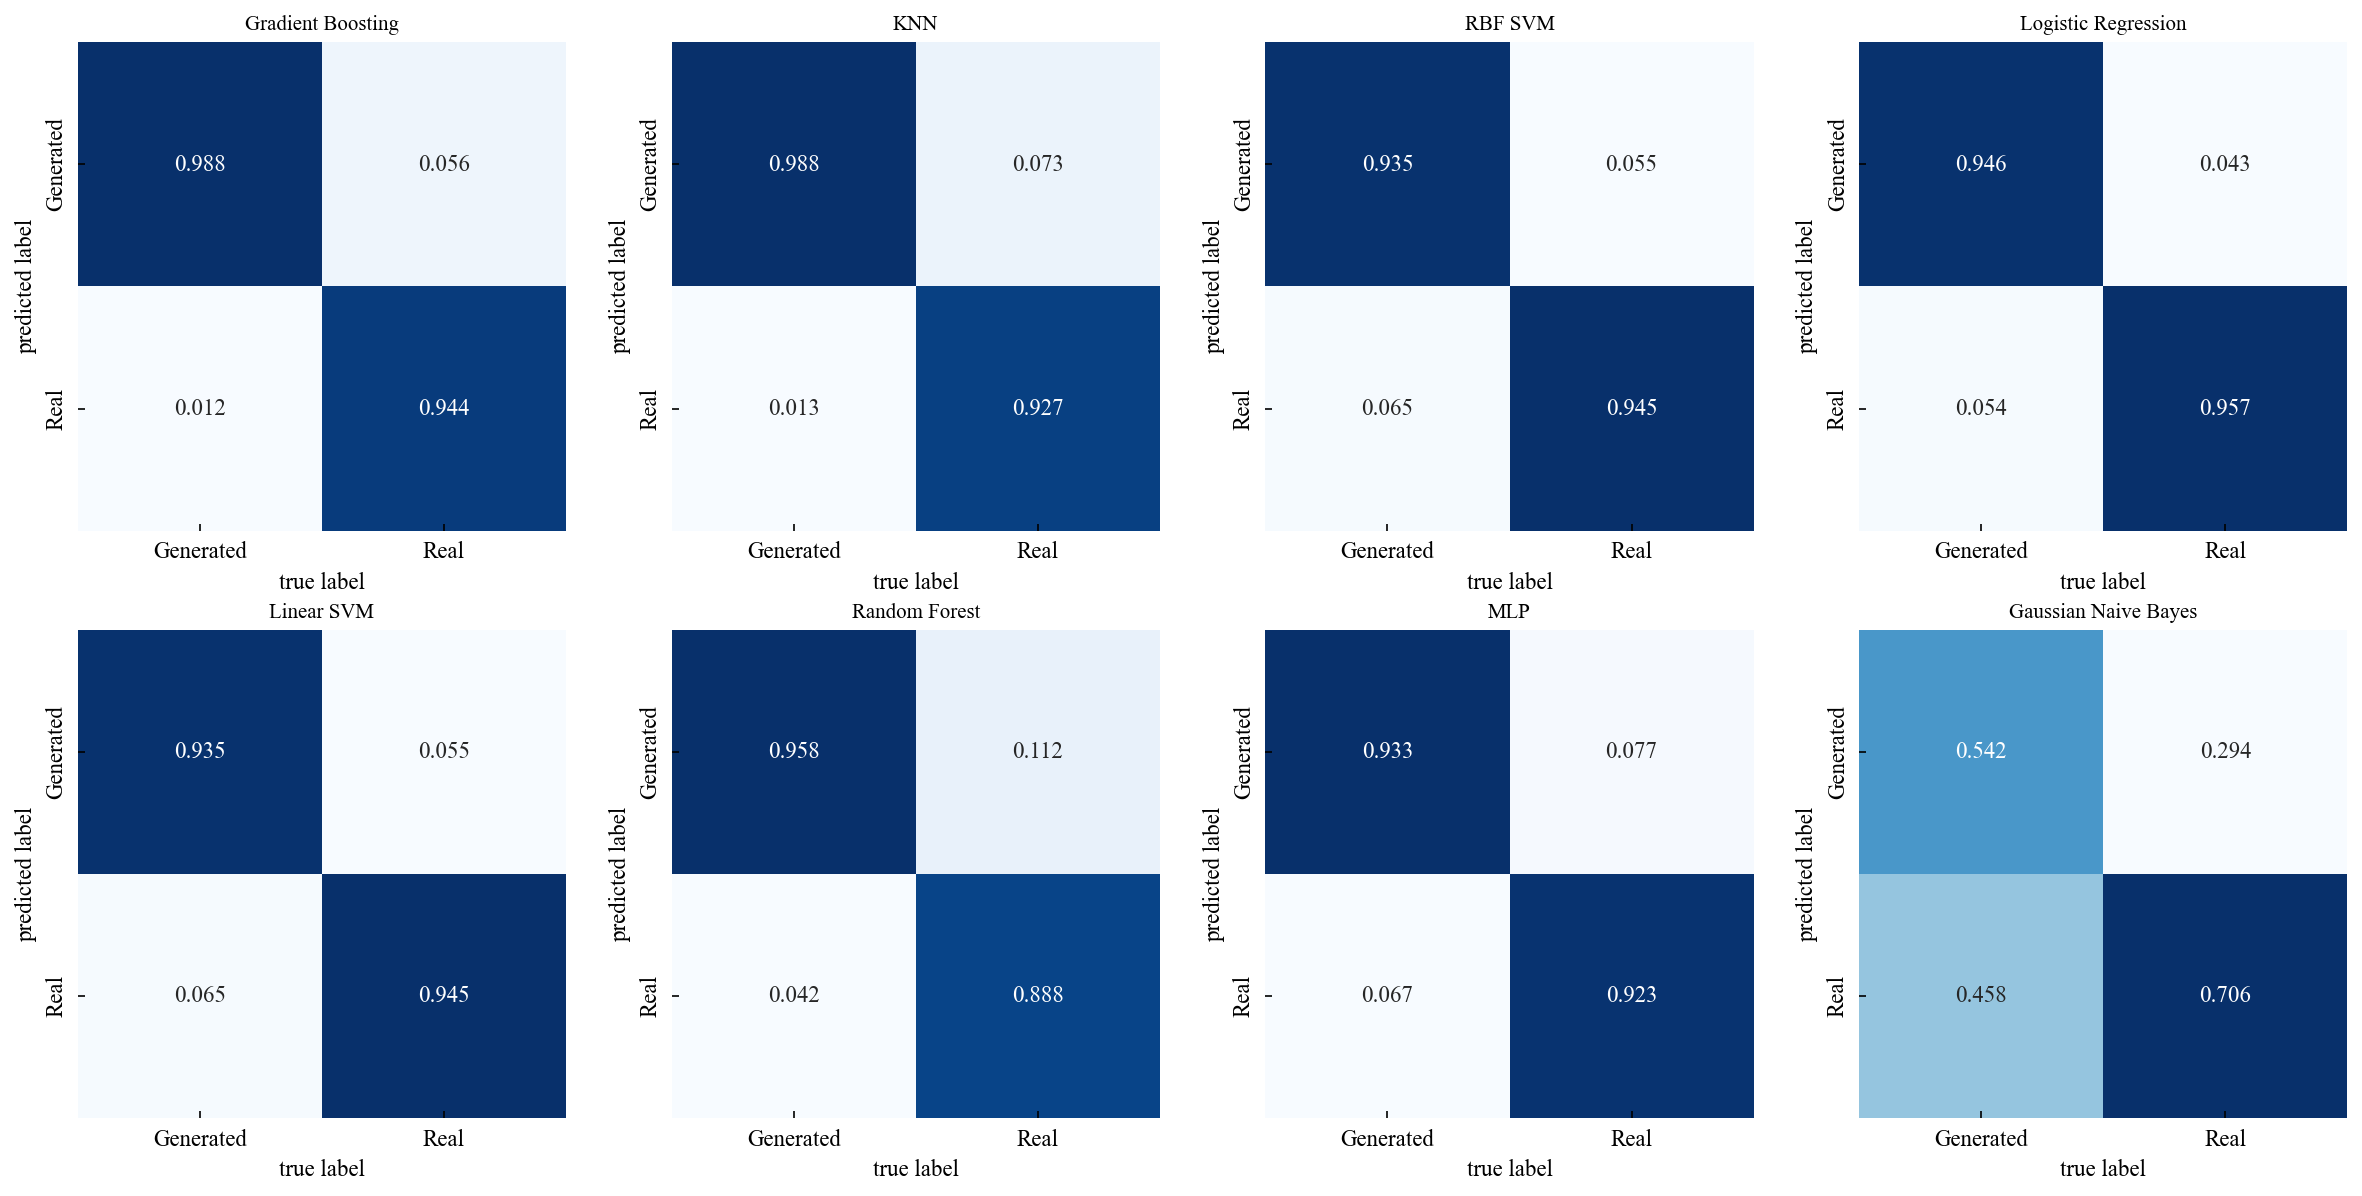

In [ ]:
class_names = ["Generated", "Real"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(len(results_df)):

    model_name = results_df.iloc[i]["model"]
    model = trained_models[model_name]
    y_pred_best = model.predict(X_test)

    conf_mat = conf_matrix(y_test, y_pred_best, class_names=class_names)

    sns.heatmap(
        conf_mat.T,
        square=True,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i]
    )

    axes[i].set_title(model_name, fontsize=10)
    axes[i].set_xlabel("true label")
    axes[i].set_ylabel("predicted label")

plt.tight_layout()
plt.show()